# `qwen3-4b-4bit-qlora-s00-r0` — two-stage canonical-answer judge

Replaces the direct-judge approach in `eval_qwen3_4b_qlora_s00_r0_essay_judge.ipynb`
with a cleaner two-stage architecture.

### Stage 1 — Ground-truth extraction (one-time, cached)
gpt-oss:20b reads each Spiceland 9e Essay/Problem gold rationale and extracts a
clean canonical answer (final answer, key numbers, required journal entries,
key concepts). The result lives in
`eval/sft/splits/seed_00__351199285/test_canonical_answers.jsonl` and is reusable
across **all** future model evaluations against this split.

### Stage 2 — Judge predictions against the canonical answer (per-run)
gpt-oss:20b receives the **canonical answer + the student's generation** (NOT
the verbose gold rationale) and decides whether the student is correct. Much
tighter task than the direct-judge approach.

### Why this is better than the direct judge
- **Cleaner judge task.** The judge matches against an explicit answer key, not
  a worked-solution paragraph. Fewer opportunities to introduce its own
  interpretation.
- **Auditable.** A human can verify the extracted canonical answers once, then
  trust judgments derived from them.
- **Reusable.** Run any new model's predictions against the same canonical file
  — only Stage 2 re-runs.
- **Decouples dataset work from model work.** Stage 1 is a property of the
  dataset; Stage 2 is per-model.

### Outputs

| Path | What | Lifecycle |
|---|---|---|
| `eval/sft/splits/seed_00__351199285/test_canonical_answers.jsonl` | one row per test record with the canonical answer | one-time write, reused across runs |
| `models/runs/qwen3-4b-4bit-qlora-s00-r0/eval_rerun/test_predictions.jsonl` | predictions updated in-place with `judge_correct`, `judge_rationale` | per-run |
| `models/runs/qwen3-4b-4bit-qlora-s00-r0/eval_rerun/test_metrics.json` | aggregate metrics with Essay/Problem now scored | per-run |

Both stages are **resumable**. Records already extracted or judged are skipped
unless `FORCE_REEXTRACT` / `FORCE_REJUDGE` is set.

## §1 — Setup + Ollama reachability probe

In [1]:
import os, sys, json, time, platform
from pathlib import Path
import urllib.request
import urllib.error

def _find_repo() -> Path:
    workspace = Path("/workspace")
    if workspace.is_dir() and (workspace / "eval" / "sft" / "splits").is_dir():
        return workspace
    forced = os.environ.get("REPO_ROOT")
    if forced:
        return Path(forced).resolve()
    p = Path.cwd().resolve()
    for d in [p, *p.parents]:
        if (d / ".git").is_dir() or (d / "eval" / "sft" / "splits").is_dir():
            return d
    raise RuntimeError(f"could not find repo root from {p}")

REPO = _find_repo()
print(f"REPO   : {REPO}")
print(f"os     : {platform.system()} {platform.release()}")
print(f"python : {platform.python_version()}")

def _probe_ollama(url: str, timeout: float = 3.0) -> bool:
    try:
        with urllib.request.urlopen(f"{url}/api/tags", timeout=timeout) as r:
            return r.status == 200
    except Exception:
        return False

CANDIDATE_URLS = []
if os.environ.get("OLLAMA_BASE_URL"):
    CANDIDATE_URLS.append(os.environ["OLLAMA_BASE_URL"].rstrip("/"))
CANDIDATE_URLS += ["http://127.0.0.1:11434", "http://172.17.0.1:11434"]

OLLAMA_URL = None
for url in CANDIDATE_URLS:
    if _probe_ollama(url):
        OLLAMA_URL = url
        break

assert OLLAMA_URL, "no Ollama instance reachable (tried: " + ", ".join(CANDIDATE_URLS) + ")"
print(f"ollama : {OLLAMA_URL}")

EXTRACTOR_MODEL = "gpt-oss:20b"
JUDGE_MODEL     = "gpt-oss:20b"

with urllib.request.urlopen(f"{OLLAMA_URL}/api/tags", timeout=5) as r:
    available = {m["name"] for m in json.loads(r.read()).get("models", [])}
for m in {EXTRACTOR_MODEL, JUDGE_MODEL}:
    assert m in available, f"{m!r} not in Ollama. Run: `ollama pull {m}`"
print(f"models : extractor={EXTRACTOR_MODEL}  judge={JUDGE_MODEL} (both verified)")

REPO   : /workspace
os     : Linux 6.14.0-1015-nvidia
python : 3.12.3
ollama : http://172.17.0.1:11434
models : extractor=gpt-oss:20b  judge=gpt-oss:20b (both verified)


## §2 — Configuration

In [2]:
RUN_ID    = "qwen3-4b-4bit-qlora-s00-r0"
RUN_DIR   = REPO / "models" / "runs" / RUN_ID
EVAL_DIR  = RUN_DIR / "eval_rerun"
PRED_PATH = EVAL_DIR / "test_predictions.jsonl"
METRICS_PATH = EVAL_DIR / "test_metrics.json"

SEED_DIR   = REPO / "eval" / "sft" / "splits" / "seed_00__351199285"
TEST_JSONL = SEED_DIR / "test.jsonl"
CANONICAL_PATH = SEED_DIR / "test_canonical_answers.jsonl"

# LLM knobs.
# gpt-oss models use a separate `thinking` channel before producing `content`.
# That reasoning eats num_predict tokens too, so budgets must be generous —
# 768 was empirically too small for extraction (model went silent). 4096/2048
# leaves ~200 content tokens of headroom after a typical thinking pass.
TEMPERATURE = 0.0
NUM_PREDICT_EXTRACT = 4096
NUM_PREDICT_JUDGE   = 2048

# Limits + resume controls
LIMIT_EXTRACT    = None    # None = all; set to e.g. 5 for a quick smoke test
LIMIT_JUDGE      = None
FORCE_REEXTRACT  = False   # True = re-run Stage 1 even if canonical_answers.jsonl already has the record
FORCE_REJUDGE    = False   # True = re-run Stage 2 even if prediction already has judge_correct

assert PRED_PATH.is_file(),   f"missing predictions: {PRED_PATH}  (run the eval notebook first)"
assert TEST_JSONL.is_file(),  f"missing test split: {TEST_JSONL}"
print(f"PRED_PATH       : {PRED_PATH}")
print(f"CANONICAL_PATH  : {CANONICAL_PATH}  ({'exists' if CANONICAL_PATH.exists() else 'will be created'})")
print(f"METRICS_PATH    : {METRICS_PATH}")

PRED_PATH       : /workspace/models/runs/qwen3-4b-4bit-qlora-s00-r0/eval_rerun/test_predictions.jsonl
CANONICAL_PATH  : /workspace/eval/sft/splits/seed_00__351199285/test_canonical_answers.jsonl  (will be created)
METRICS_PATH    : /workspace/models/runs/qwen3-4b-4bit-qlora-s00-r0/eval_rerun/test_metrics.json


## §3 — Stage 1: extract canonical ground-truth answers (gpt-oss:20b)

For each test record, produce a clean answer key. Deterministic for
MC/TF/Matching (regex over the assistant turn). LLM-extracted for
Essay/Problem (the verbose worked-solution prose is condensed to a
final answer + key numbers + required journal entries + key concepts).

### §3.1 — Extraction helpers

In [3]:
import re

def deterministic_gold(rec: dict) -> dict | None:
    """Return a canonical answer for MC/TF/Matching. None for Essay/Problem."""
    asst = rec["messages"][2]["content"].strip()
    qtype = rec["meta"]["type"]
    if qtype == "Multiple Choice":
        m = re.match(r"^\*\*([A-E])\*\*", asst)
        ans = m.group(1) if m else asst[:1]
        return {"final_answer": ans, "numeric_values": [], "journal_entries": [], "key_concepts": [], "extraction_confidence": "high"}
    if qtype == "True/False":
        m = re.match(r"^\*\*(TRUE|FALSE)\*\*", asst, re.IGNORECASE)
        ans = m.group(1).upper() if m else asst.upper().split()[0]
        return {"final_answer": ans, "numeric_values": [], "journal_entries": [], "key_concepts": [], "extraction_confidence": "high"}
    if qtype == "Matching":
        m = re.match(r"^([A-Z])\b", asst)
        ans = m.group(1) if m else asst[:1]
        return {"final_answer": ans, "numeric_values": [], "journal_entries": [], "key_concepts": [], "extraction_confidence": "high"}
    return None  # Essay/Problem — needs LLM extraction

EXTRACTOR_SYSTEM = (
    "You extract canonical ground-truth answers from Spiceland 9e accounting "
    "solution-manual entries. You DO NOT solve the problem yourself — you read "
    "the solution manual's verbose answer and condense it into a clean answer "
    "key that future graders will compare student answers against. Output "
    "strict JSON only."
)

EXTRACTOR_INSTRUCTIONS = '''Extract the canonical ground-truth answer from this Spiceland 9e solution-manual entry.

Return strict JSON with these fields:
- "final_answer": ONE sentence (or a short JE list) stating the bottom-line answer
  that any correct student response must convey. No explanation, no calculation
  steps — just the conclusion. For numerical problems: state the final number with
  units. For conceptual problems: state the answer.
- "numeric_values": list of key dollar amounts, percentages, or quantities that a
  correct answer MUST contain. Use exact numbers from the gold (no commas, no $).
  Empty list if not applicable.
- "journal_entries": list of {"account": str, "debit": float|null, "credit": float|null}
  dicts if the gold prescribes journal entries. Empty list otherwise.
- "key_concepts": list of up to 5 accounting concepts/terms a correct answer must
  reference (e.g., "straight-line depreciation", "matching principle"). Empty list
  if the question is purely computational.
- "extraction_confidence": "high" if the gold has a clear single answer, "medium"
  if minor ambiguity, "low" if the gold itself is multi-part or ambiguous.

Example:
{"final_answer": "Depreciation expense for 2025 is $48,000.",
 "numeric_values": [48000],
 "journal_entries": [],
 "key_concepts": ["straight-line depreciation"],
 "extraction_confidence": "high"}

Output JSON only — no surrounding prose.'''

def build_extract_prompt(rec: dict) -> str:
    user_q  = rec["messages"][1]["content"]
    gold    = rec["messages"][2]["content"]
    qid     = rec["meta"]["id"]
    qtype   = rec["meta"]["type"]
    return (
        f"=== Question ID: {qid}  ({qtype}) ===\n\n"
        f"--- Question ---\n{user_q}\n\n"
        f"--- Gold-standard answer from Spiceland 9e solution manual ---\n{gold}\n\n"
        f"{EXTRACTOR_INSTRUCTIONS}"
    )

def call_ollama_json(model: str, system: str, user: str, *,
                     num_predict: int, timeout: float = 180.0) -> tuple[dict, float]:
    """Call Ollama /api/chat with format=json, return (parsed_json, latency_s)."""
    body = json.dumps({
        "model": model,
        "messages": [
            {"role": "system", "content": system},
            {"role": "user",   "content": user},
        ],
        "format": "json",
        "stream": False,
        "options": {"temperature": TEMPERATURE, "num_predict": num_predict},
    }).encode("utf-8")
    req = urllib.request.Request(
        f"{OLLAMA_URL}/api/chat",
        data=body,
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    t0 = time.time()
    with urllib.request.urlopen(req, timeout=timeout) as r:
        raw = json.loads(r.read())
    elapsed = time.time() - t0
    content = raw.get("message", {}).get("content", "").strip()
    try:
        parsed = json.loads(content)
    except json.JSONDecodeError:
        m = re.search(r"\{.*\}", content, flags=re.DOTALL)
        parsed = json.loads(m.group(0)) if m else {}
    return parsed, elapsed

### §3.2 — Run extraction (resumable, cached)

In [4]:
# Load test split + existing canonical (if any)
test_records = []
with TEST_JSONL.open(encoding="utf-8") as fh:
    for line in fh:
        line = line.strip()
        if line:
            test_records.append(json.loads(line))
test_by_id = {r["meta"]["id"]: r for r in test_records}
print(f"loaded {len(test_records)} test records from {TEST_JSONL.name}")

canonical_by_id: dict[str, dict] = {}
if CANONICAL_PATH.exists():
    with CANONICAL_PATH.open(encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if line:
                row = json.loads(line)
                canonical_by_id[row["question_id"]] = row
    print(f"loaded {len(canonical_by_id)} cached canonical answers from {CANONICAL_PATH.name}")
else:
    print(f"no existing canonical file — will create {CANONICAL_PATH.name}")

loaded 464 test records from test.jsonl
no existing canonical file — will create test_canonical_answers.jsonl


In [5]:
# Build the work queue
def _needs_extract(rec):
    qid = rec["meta"]["id"]
    if FORCE_REEXTRACT:
        return True
    return qid not in canonical_by_id

# Apply deterministic extractor immediately for MC/TF/Matching, queue LLM extract for Essay/Problem
det_extracted = 0
todo_essay = []
for rec in test_records:
    if not _needs_extract(rec):
        continue
    qid   = rec["meta"]["id"]
    qtype = rec["meta"]["type"]
    det = deterministic_gold(rec)
    if det is not None:
        canonical_by_id[qid] = {
            "question_id"            : qid,
            "type"                   : qtype,
            **det,
            "extracted_by"           : "regex",
            "extracted_at"           : time.strftime("%Y-%m-%dT%H:%M:%S%z"),
        }
        det_extracted += 1
    else:
        todo_essay.append(rec)

print(f"deterministic-extracted (MC/TF/Matching): {det_extracted}")
print(f"queued for LLM extract (Essay/Problem)  : {len(todo_essay)}")
if LIMIT_EXTRACT is not None:
    todo_essay = todo_essay[:LIMIT_EXTRACT]
    print(f"LIMIT_EXTRACT applied: will LLM-extract {len(todo_essay)} this run")

deterministic-extracted (MC/TF/Matching): 347
queued for LLM extract (Essay/Problem)  : 117


In [6]:
from tqdm.auto import tqdm

def _flush_canonical():
    # Sort by question_id for stable diffs
    rows = sorted(canonical_by_id.values(), key=lambda r: r["question_id"])
    with CANONICAL_PATH.open("w", encoding="utf-8") as fh:
        for row in rows:
            fh.write(json.dumps(row, ensure_ascii=False) + "\n")

# Flush deterministic extractions first (cheap; no LLM cost to lose on interrupt)
_flush_canonical()

errors = 0
t0 = time.time()
for rec in tqdm(todo_essay, desc="extracting ground truth"):
    qid = rec["meta"]["id"]
    try:
        verdict, latency = call_ollama_json(
            EXTRACTOR_MODEL, EXTRACTOR_SYSTEM, build_extract_prompt(rec),
            num_predict=NUM_PREDICT_EXTRACT,
        )
    except Exception as exc:  # noqa: BLE001
        errors += 1
        canonical_by_id[qid] = {
            "question_id": qid, "type": rec["meta"]["type"],
            "error": f"{type(exc).__name__}: {exc!s:.300}",
            "extracted_by": EXTRACTOR_MODEL,
            "extracted_at": time.strftime("%Y-%m-%dT%H:%M:%S%z"),
        }
        _flush_canonical()
        continue

    canonical_by_id[qid] = {
        "question_id"            : qid,
        "type"                   : rec["meta"]["type"],
        "final_answer"           : str(verdict.get("final_answer", "")).strip(),
        "numeric_values"         : verdict.get("numeric_values", []) or [],
        "journal_entries"        : verdict.get("journal_entries", []) or [],
        "key_concepts"           : verdict.get("key_concepts", []) or [],
        "extraction_confidence"  : verdict.get("extraction_confidence", "unknown"),
        "extracted_by"           : EXTRACTOR_MODEL,
        "extracted_at"           : time.strftime("%Y-%m-%dT%H:%M:%S%z"),
        "extract_latency_ms"     : round(latency * 1000, 1),
    }
    _flush_canonical()

elapsed = time.time() - t0
print(f"\nstage 1 done: extracted {len(todo_essay) - errors}/{len(todo_essay)} essay records in {elapsed:.1f}s")
if errors:
    print(f"  errors: {errors} (records carry an `error` field)")
print(f"canonical answers file now has {len(canonical_by_id)} rows: {CANONICAL_PATH}")

extracting ground truth:   0%|          | 0/117 [00:00<?, ?it/s]


stage 1 done: extracted 117/117 essay records in 1548.8s
canonical answers file now has 464 rows: /workspace/eval/sft/splits/seed_00__351199285/test_canonical_answers.jsonl


### §3.3 — Spot-check a few extracted canonical answers

Pick 3 essay records and print the gold vs the extracted canonical side-by-side
so a human can verify the extractor isn't drifting.

In [7]:
essay_canonical = [c for c in canonical_by_id.values() if c["type"] == "Essay/Problem" and "final_answer" in c]
sample = essay_canonical[:3]
for c in sample:
    rec = test_by_id[c["question_id"]]
    print(f"=== {c['question_id']}  (confidence={c.get('extraction_confidence','?')}) ===")
    print("  GOLD (first 400 ch):")
    print("    " + rec["messages"][2]["content"][:400].replace("\n", "\n    "))
    print(f"  CANONICAL final_answer:")
    print(f"    {c['final_answer']}")
    print(f"  numeric_values  : {c['numeric_values']}")
    print(f"  journal_entries : {c['journal_entries']}")
    print(f"  key_concepts    : {c['key_concepts']}")
    print()

=== ch01_q0171_es  (confidence=high) ===
  GOLD (first 400 ch):
    The Securities and Exchange Commission is a federal agency that has the authority to set accounting standards. However, the SEC has always relied on a private-sector body, such as the current FASB, to accomplish that task.
  CANONICAL final_answer:
    The SEC is a federal agency that has the authority to set accounting standards, but it relies on a private-sector body such as the FASB to accomplish that task.
  numeric_values  : []
  journal_entries : []
  key_concepts    : ['SEC', 'accounting standard-setting', 'FASB', 'private-sector body']

=== ch01_q0179_es  (confidence=high) ===
  GOLD (first 400 ch):
    Periodicity—The life of a company can be divided into artificial periods to provide timely information to external users.
    Monetary unit—In the United States, financial statement elements should be measured in terms of the U.S. dollar. It assumes that the value of a dollar is stable over time.
    
    Moneta

## §4 — Stage 2: judge predictions against canonical answers

### §4.1 — Judge helpers

In [8]:
def extract_predicted(qtype: str, generation: str):
    g = (generation or "").strip()
    if not g: return None
    if qtype == "Multiple Choice":
        m = re.search(r"\*\*([A-E])\*\*", g)
        if m: return m.group(1)
        m = re.search(r"\b([A-E])\b", g)
        return m.group(1) if m else None
    if qtype == "True/False":
        if re.search(r"\b(TRUE|True|true)\b", g):  return "TRUE"
        if re.search(r"\b(FALSE|False|false)\b", g): return "FALSE"
        return None
    if qtype == "Matching":
        m = re.search(r"\b([A-Z])\b", g)
        if m: return m.group(1)
        m = re.search(r"\b(\d{1,2})\b", g)
        return m.group(1) if m else None
    return g

SCORABLE_TYPES = {"Multiple Choice", "True/False", "Matching"}

JUDGE_SYSTEM = (
    "You compare a student's accounting answer against a canonical ground-truth "
    "answer key. You do NOT re-solve the problem; you check whether the student's "
    "final answer matches the answer key. Output strict JSON only."
)

JUDGE_INSTRUCTIONS = '''Compare the student's answer against the canonical ground-truth answer key.

Mark "correct": true if the student's answer matches the canonical answer, allowing for:
- different phrasing or formatting (as long as the substance is the same)
- rounding differences within 1% on numeric values
- different ordering of journal entry lines (as long as accounts + debit/credit + amounts match)
- additional explanation that doesn't contradict the canonical answer

Mark "correct": false if:
- any required numeric value is wrong or missing
- any required journal entry is wrong or missing
- the substantive conclusion differs from the canonical
- the student gave no answer

Return strict JSON: {"correct": true|false, "rationale": "one short sentence"}.
Output JSON only.'''

def build_judge_prompt(canonical: dict, prediction: dict) -> str:
    return (
        f"=== Question ID: {canonical['question_id']}  ({canonical['type']}) ===\n\n"
        f"--- Canonical ground-truth answer key ---\n"
        f"Final answer: {canonical.get('final_answer','')}\n"
        f"Required numeric values: {canonical.get('numeric_values', [])}\n"
        f"Required journal entries: {json.dumps(canonical.get('journal_entries', []), ensure_ascii=False)}\n"
        f"Key concepts: {canonical.get('key_concepts', [])}\n\n"
        f"--- Student's answer ---\n{prediction['generation']}\n\n"
        f"{JUDGE_INSTRUCTIONS}"
    )

### §4.2 — Run judge over predictions

For MC/TF/Matching: deterministic comparison (regex extract → string equality).
For Essay/Problem: LLM compares the student's free-form output against the
canonical answer key from Stage 1.

In [9]:
# Load predictions
predictions = []
with PRED_PATH.open(encoding="utf-8") as fh:
    for line in fh:
        line = line.strip()
        if line:
            predictions.append(json.loads(line))
print(f"loaded {len(predictions)} predictions")

# Decide which records to judge
def _needs_judge(p):
    if FORCE_REJUDGE:
        return True
    # If type is Essay/Problem, judge if no canonical-judge verdict yet
    if p["type"] == "Essay/Problem":
        return p.get("judge_method") != "canonical_v2" or "judge_correct" not in p
    # For MC/TF/Matching, always re-score deterministically against canonical (cheap)
    return True

todo = [i for i, p in enumerate(predictions) if _needs_judge(p)]
print(f"to judge: {len(todo)} records (MC/TF/Matching are deterministic; Essay/Problem calls the LLM)")
if LIMIT_JUDGE is not None:
    todo = todo[:LIMIT_JUDGE]
    print(f"LIMIT_JUDGE applied: will judge {len(todo)} this run")

loaded 464 predictions
to judge: 464 records (MC/TF/Matching are deterministic; Essay/Problem calls the LLM)


In [10]:
JUDGE_LOG = EVAL_DIR / "judge_log_canonical.jsonl"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

def _flush_predictions():
    with PRED_PATH.open("w", encoding="utf-8") as fh:
        for p in predictions:
            fh.write(json.dumps(p, ensure_ascii=False) + "\n")

def _append_log(entry):
    with JUDGE_LOG.open("a", encoding="utf-8") as fh:
        fh.write(json.dumps(entry, ensure_ascii=False) + "\n")

llm_calls = 0
det_scored = 0
errors = 0
t0 = time.time()

for i in tqdm(todo, desc="judging"):
    p = predictions[i]
    qid = p["question_id"]
    canonical = canonical_by_id.get(qid)
    if not canonical or "final_answer" not in canonical:
        errors += 1
        p["judge_method"]   = "canonical_v2"
        p["judge_correct"]  = False
        p["judge_rationale"] = f"no canonical answer for {qid} (extraction failed or not yet run)"
        p["judge_pending"]  = False
        p["scorable"]       = False
        continue

    if p["type"] in SCORABLE_TYPES:
        # Deterministic re-score against canonical letter/TF/letter
        student_pred = extract_predicted(p["type"], p["generation"])
        canonical_ans = (canonical.get("final_answer") or "").strip().upper()
        student_norm  = (student_pred or "").strip().upper()
        correct = bool(canonical_ans and student_norm and canonical_ans == student_norm)
        p["pred"]    = student_pred
        p["gold"]    = canonical.get("final_answer")
        p["correct"] = correct
        p["scorable"]      = True
        p["judge_pending"] = False
        p["judge_method"]  = "canonical_v2"
        p["judge_correct"] = correct
        p["judge_rationale"] = "deterministic match against canonical" if correct else "deterministic mismatch against canonical"
        det_scored += 1
    else:
        # Essay/Problem — LLM judge against canonical
        try:
            verdict, latency = call_ollama_json(
                JUDGE_MODEL, JUDGE_SYSTEM, build_judge_prompt(canonical, p),
                num_predict=NUM_PREDICT_JUDGE,
            )
        except Exception as exc:  # noqa: BLE001
            errors += 1
            _append_log({"question_id": qid, "error": f"{type(exc).__name__}: {exc!s:.300}",
                         "ts": time.strftime("%Y-%m-%dT%H:%M:%S%z")})
            continue

        is_correct = bool(verdict.get("correct", False))
        p["correct"]        = is_correct
        p["scorable"]       = True
        p["judge_pending"]  = False
        p["judge_method"]   = "canonical_v2"
        p["judge_correct"]  = is_correct
        p["judge_rationale"] = str(verdict.get("rationale", "")).strip()
        p["judge_model"]    = JUDGE_MODEL
        p["judge_latency_ms"] = round(latency * 1000, 1)
        llm_calls += 1

        _append_log({
            "question_id": qid,
            "verdict"    : {"correct": is_correct, "rationale": p["judge_rationale"]},
            "canonical_final_answer": canonical.get("final_answer"),
            "latency_ms" : p["judge_latency_ms"],
            "ts"         : time.strftime("%Y-%m-%dT%H:%M:%S%z"),
        })

    _flush_predictions()

elapsed = time.time() - t0
print(f"\nstage 2 done in {elapsed:.1f}s: {det_scored} deterministic + {llm_calls} LLM judgments, {errors} errors")

judging:   0%|          | 0/464 [00:00<?, ?it/s]


stage 2 done in 682.9s: 347 deterministic + 117 LLM judgments, 0 errors


## §5 — Re-aggregate `test_metrics.json`

In [11]:
from collections import defaultdict

def _ab():
    return {"correct": 0, "scorable": 0, "judge_pending": 0}

by_type, by_bloom, by_chapter, overall = defaultdict(_ab), defaultdict(_ab), defaultdict(_ab), _ab()
for p in predictions:
    for b in (by_type[p["type"]], by_bloom[p["primary_bloom"]], by_chapter[p["chapter"]], overall):
        if p.get("judge_pending"):
            b["judge_pending"] += 1
        else:
            b["scorable"] += 1
            if p["correct"]:
                b["correct"] += 1

def _wacc(b):
    return {**b, "accuracy": (b["correct"] / b["scorable"]) if b["scorable"] else None}

prev = json.loads(METRICS_PATH.read_text(encoding="utf-8")) if METRICS_PATH.exists() else {}
metrics = {
    **prev,
    "generated_at"      : time.strftime("%Y-%m-%dT%H:%M:%S%z"),
    "n_questions"       : len(predictions),
    "n_scorable"        : overall["scorable"],
    "n_judge_pending"   : overall["judge_pending"],
    "overall_accuracy_scorable": round(overall["correct"] / overall["scorable"], 4) if overall["scorable"] else None,
    "by_question_type"  : {k: _wacc(v) for k, v in by_type.items()},
    "by_primary_bloom"  : {k: _wacc(v) for k, v in sorted(by_bloom.items())},
    "by_chapter"        : {str(k): _wacc(v) for k, v in sorted(by_chapter.items())},
    "judge": {
        "method"        : "canonical_v2",
        "extractor_model": EXTRACTOR_MODEL,
        "judge_model"   : JUDGE_MODEL,
        "canonical_path": str(CANONICAL_PATH),
        "n_essay_llm_judgments": sum(1 for p in predictions if p["type"] == "Essay/Problem" and p.get("judge_method") == "canonical_v2"),
    },
}
METRICS_PATH.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
print(f"wrote {METRICS_PATH}")
print()
print(f"=== overall: {metrics['overall_accuracy_scorable']:.2%}  ({overall['correct']}/{overall['scorable']}) ===")
for t, v in metrics["by_question_type"].items():
    acc = f"{v['accuracy']:.2%}" if v["accuracy"] is not None else "  —  "
    print(f"  {t:<18s}: {acc}  ({v['correct']}/{v['scorable']})")

wrote /workspace/models/runs/qwen3-4b-4bit-qlora-s00-r0/eval_rerun/test_metrics.json

=== overall: 62.28%  (289/464) ===
  Multiple Choice   : 64.10%  (150/234)
  Essay/Problem     : 38.46%  (45/117)
  True/False        : 75.00%  (30/40)
  Matching          : 87.67%  (64/73)


## §6 — Visualize

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

### 6.1 — Accuracy by question type

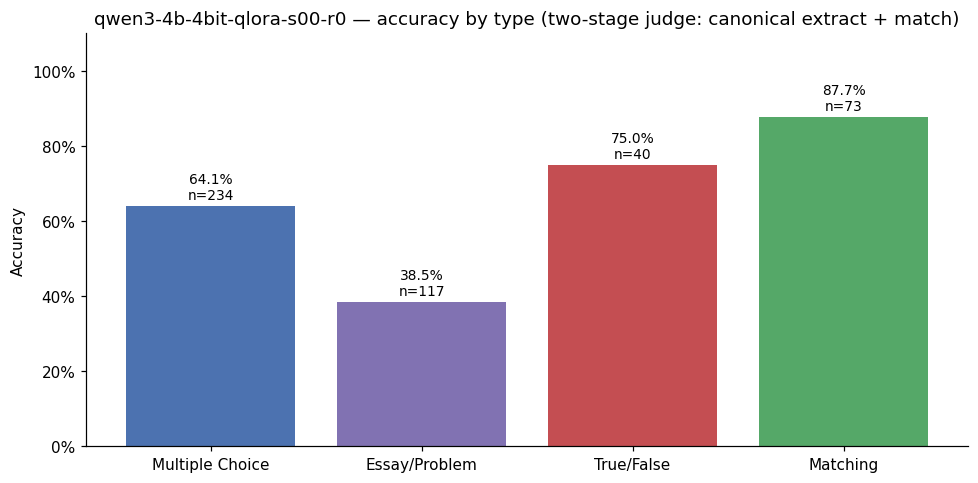

In [13]:
types = list(metrics["by_question_type"].keys())
type_acc = [metrics["by_question_type"][t]["accuracy"] or 0.0 for t in types]
type_n   = [metrics["by_question_type"][t]["scorable"]      for t in types]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(types, type_acc, color=["#4C72B0", "#8172B2", "#C44E52", "#55A868"])
for b, n, acc in zip(bars, type_n, type_acc):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{acc:.1%}\nn={n}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.10)
ax.set_ylabel("Accuracy")
ax.set_title(f"{RUN_ID} — accuracy by type (two-stage judge: canonical extract + match)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout()
plt.show()

### 6.2 — Accuracy by primary Bloom

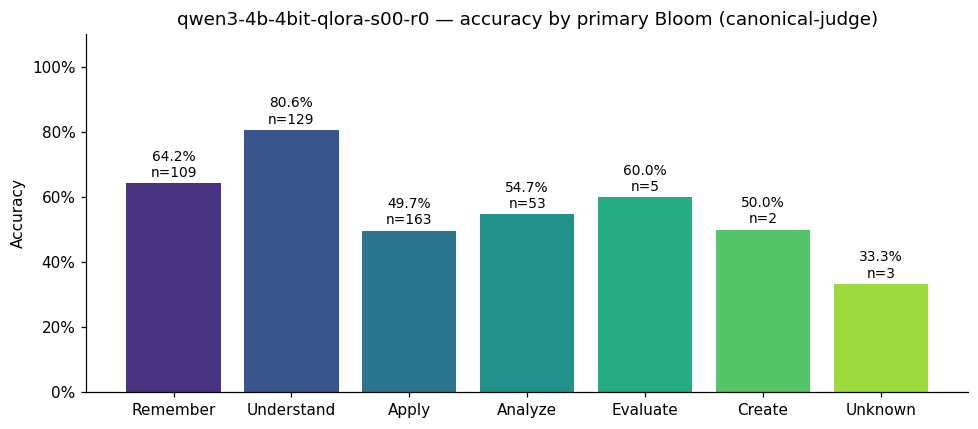

In [14]:
BLOOM_ORDER = ["Remember", "Understand", "Apply", "Analyze", "Evaluate", "Create"]
blooms = [b for b in BLOOM_ORDER if b in metrics["by_primary_bloom"]]
blooms += [b for b in metrics["by_primary_bloom"] if b not in BLOOM_ORDER]
bloom_acc = [metrics["by_primary_bloom"][b]["accuracy"] or 0.0 for b in blooms]
bloom_n   = [metrics["by_primary_bloom"][b]["scorable"]      for b in blooms]

fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(blooms)))
bars = ax.bar(blooms, bloom_acc, color=colors)
for b, n, acc in zip(bars, bloom_n, bloom_acc):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{acc:.1%}\nn={n}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.10)
ax.set_ylabel("Accuracy")
ax.set_title(f"{RUN_ID} — accuracy by primary Bloom (canonical-judge)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout()
plt.show()

### 6.3 — Side-by-side: direct-judge (v1) vs canonical-judge (v2) on Essay/Problem

If the direct-judge log is still on disk (`judge_log.jsonl`), compare per-record
verdicts. Disagreements are the cohort worth manually reviewing — they're where
the two approaches differ in their reading of the gold.

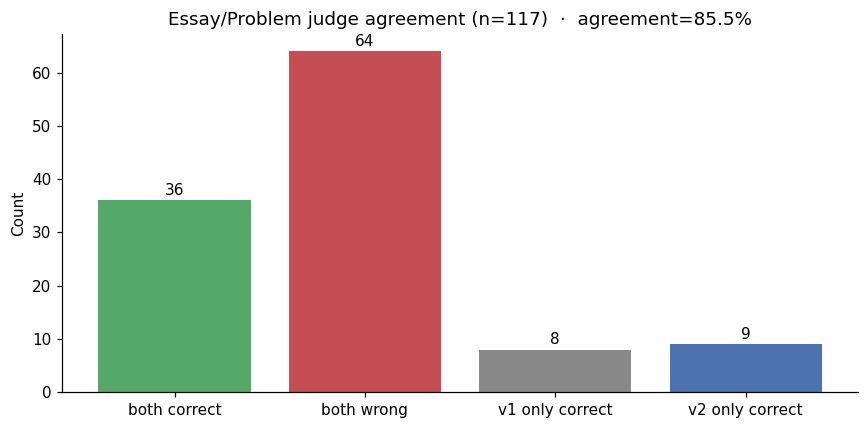


17 disagreements (showing first 5):
  ch07_q0176_es: v1=True v2=False  v2_rationale: Student omitted the key detail that the account offsets Loans Receivable.
  ch07_q0178_es: v1=False v2=True  v2_rationale: Student describes timing provisions to overstate allowance in good periods and reduce charges later, matching the canoni
  ch07_q0179_es: v1=False v2=True  v2_rationale: Student’s conclusion matches the canonical answer.
  ch07_q0181_es: v1=False v2=True  v2_rationale: The student’s percentage (1.43%) is within the acceptable 1% tolerance of the required 1.41%.
  ch07_q0205_es: v1=True v2=False  v2_rationale: Student omitted the required journal entries.


In [15]:
prev_log = EVAL_DIR / "judge_log.jsonl"
v1_verdicts = {}
if prev_log.exists():
    with prev_log.open(encoding="utf-8") as fh:
        for line in fh:
            row = json.loads(line)
            if "verdict" in row:
                v1_verdicts[row["question_id"]] = row["verdict"]["correct"]

if not v1_verdicts:
    print(f"no direct-judge log at {prev_log} — skipping comparison")
else:
    essay = [p for p in predictions if p["type"] == "Essay/Problem" and p.get("judge_method") == "canonical_v2"]
    agree_correct = agree_wrong = v1_only = v2_only = 0
    disagreements = []
    for p in essay:
        v1 = v1_verdicts.get(p["question_id"])
        v2 = bool(p.get("judge_correct", False))
        if v1 is None:
            continue
        if v1 and v2:       agree_correct += 1
        elif (not v1) and (not v2): agree_wrong += 1
        elif v1 and not v2: v1_only += 1
        else:               v2_only += 1
        if v1 != v2:
            disagreements.append((p["question_id"], v1, v2, p.get("judge_rationale", "")[:120]))

    total = agree_correct + agree_wrong + v1_only + v2_only
    fig, ax = plt.subplots(figsize=(8, 4))
    cats = ["both correct", "both wrong", "v1 only correct", "v2 only correct"]
    vals = [agree_correct, agree_wrong, v1_only, v2_only]
    cols = ["#55A868", "#C44E52", "#888888", "#4C72B0"]
    bars = ax.bar(cats, vals, color=cols)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5, str(v), ha="center", va="bottom", fontsize=10)
    ax.set_ylabel("Count")
    ax.set_title(f"Essay/Problem judge agreement (n={total})  ·  agreement={100*(agree_correct+agree_wrong)/total:.1f}%")
    plt.tight_layout()
    plt.show()

    if disagreements:
        print(f"\n{len(disagreements)} disagreements (showing first 5):")
        for qid, v1, v2, rat in disagreements[:5]:
            print(f"  {qid}: v1={v1} v2={v2}  v2_rationale: {rat}")

## Re-using the canonical answers for r1, r2, …

`eval/sft/splits/seed_00__351199285/test_canonical_answers.jsonl` is a property
of the **dataset**, not the model. Future model evaluations against this same
seed_00 split should reuse it directly — only Stage 2 (the judge over
predictions) needs to re-run. Skip Stage 1 by leaving `FORCE_REEXTRACT=False`;
records already present in `canonical_by_id` are not re-extracted.

If the underlying test split is regenerated (e.g., a new corpus version),
either delete the file or set `FORCE_REEXTRACT=True` to refresh.